
1. DATASET SIZE
Rows    : 2800
Columns : 10

2. FIRST 5 ROWS


,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No



3. COLUMN INFORMATION


,Column,Data Type,Missing Values,Unique Values
employee_id,employee_id,int64,0,2800
department,department,str,0,6
role_level,role_level,str,0,3
monthly_salary,monthly_salary,int64,0,2753
avg_weekly_hours,avg_weekly_hours,int64,0,31
projects_handled,projects_handled,int64,0,8
performance_rating,performance_rating,int64,0,5
absences_days,absences_days,int64,0,21
job_satisfaction,job_satisfaction,int64,0,5
attrition,attrition,str,0,2



4. DUPLICATES
Duplicate rows: 0

5. MISSING VALUES
No missing values found.

6. NUMERICAL COLUMNS
['employee_id', 'monthly_salary', 'avg_weekly_hours', 'projects_handled', 'performance_rating', 'absences_days', 'job_satisfaction']

7. CATEGORICAL COLUMNS
['department', 'role_level', 'attrition']

8. NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
employee_id,2800.0,1400.500000,808.434702,1.0,700.75,1400.5,2100.25,2800.0
monthly_salary,2800.0,74492.075000,25899.209391,30006.0,51665.00,74587.5,97249.50,119977.0
avg_weekly_hours,2800.0,49.842500,8.980976,35.0,42.00,50.0,57.00,65.0
projects_handled,2800.0,4.519286,2.286778,1.0,3.00,4.0,7.00,8.0
performance_rating,2800.0,2.960714,1.404794,1.0,2.00,3.0,4.00,5.0
absences_days,2800.0,9.995000,6.056656,0.0,5.00,10.0,15.00,20.0
job_satisfaction,2800.0,2.995357,1.414332,1.0,2.00,3.0,4.00,5.0



9. ATTRITION DISTRIBUTION

Count:
attrition
No     1660
Yes    1140
Name: count, dtype: int64

Percentage:
attrition
No     59.29
Yes    40.71
Name: proportion, dtype: float64

10. CATEGORICAL VALUE COUNTS

 department
department
Marketing      494
HR             478
Engineering    469
Operations     464
Finance        461
Sales          434
Name: count, dtype: int64

 role_level
role_level
Senior    953
Mid       932
Junior    915
Name: count, dtype: int64

 attrition
attrition
No     1660
Yes    1140
Name: count, dtype: int64

11. TARGET ENCODING
Unique target values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

12. NUMERICAL FEATURES BY ATTRITION

 monthly_salary
attrition
No     74677.40
Yes    74222.21
Name: monthly_salary, dtype: float64

 avg_weekly_hours
attrition
No     49.03
Yes    51.03
Name: avg_weekly_hours, dtype: float64

 projects_handled
attrition
No     4.50
Yes    4.55
Name: projects_handled, dtype: float64

 performance_rating
attrition
No     3.17
Yes    2.6

,Correlation with Attrition
absences_days,0.162623
avg_weekly_hours,0.109173
projects_handled,0.012404
monthly_salary,-0.008636
employee_id,-0.019922
performance_rating,-0.178151
job_satisfaction,-0.246088



14. FEATURES MOST RELATED TO ATTRITION
absences_days             : 0.163
avg_weekly_hours          : 0.109
projects_handled          : 0.012
monthly_salary            : -0.009
employee_id               : -0.020
performance_rating        : -0.178
job_satisfaction          : -0.246

15. VISUAL ANALYSIS


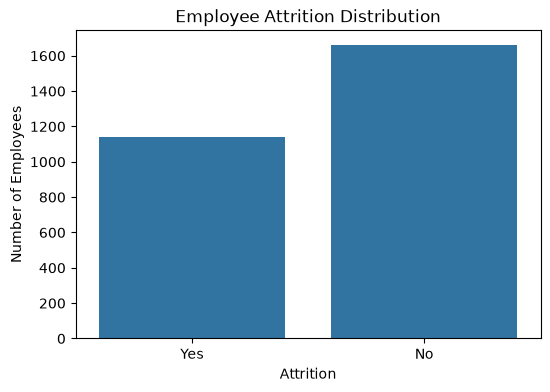

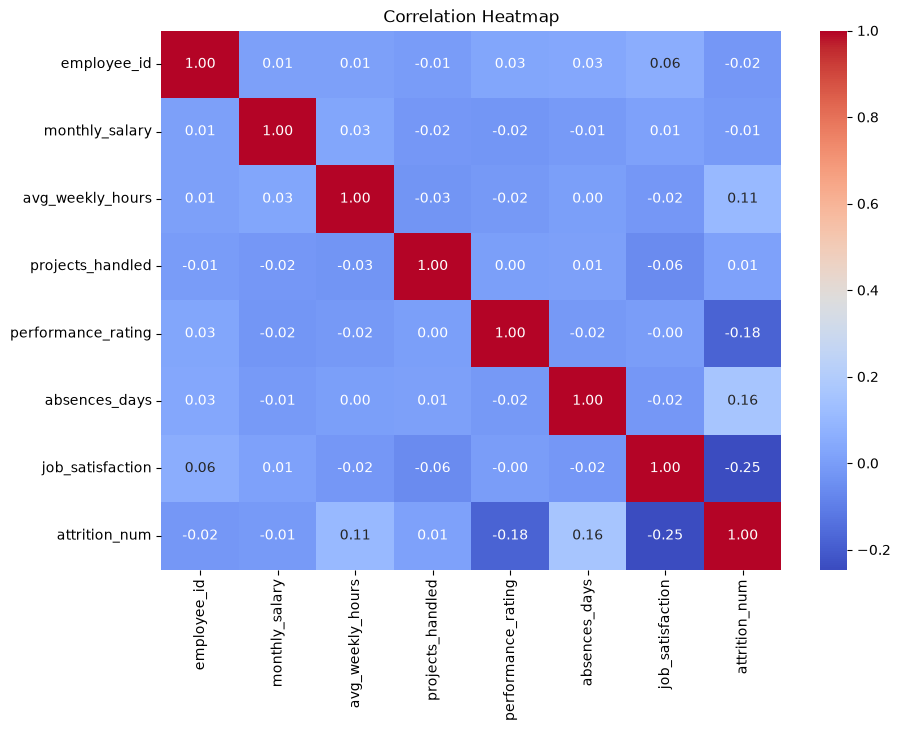

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("attrition.csv")



# 1. Dataset size
print("\n1. DATASET SIZE")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# 2. First 5 rows
print("\n2. FIRST 5 ROWS")
display(df.head())

# 3. Column information
print("\n3. COLUMN INFORMATION")
info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})
display(info)

# 4. Duplicate rows
print("\n4. DUPLICATES")
print("Duplicate rows:", df.duplicated().sum())

# 5. Missing values
print("\n5. MISSING VALUES")
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing)

# 6. Numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print("\n6. NUMERICAL COLUMNS")
print(num_cols)

# 7. Categorical columns
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("\n7. CATEGORICAL COLUMNS")
print(cat_cols)

# 8. Numerical summary
print("\n8. NUMERICAL SUMMARY")
display(df[num_cols].describe().T)

# 9. Target distribution
print("\n9. ATTRITION DISTRIBUTION")

print("\nCount:")
print(df["attrition"].value_counts())

print("\nPercentage:")
print((df["attrition"].value_counts(normalize=True) * 100).round(2))

# 10. Unique values of categorical columns
print("\n10. CATEGORICAL VALUE COUNTS")

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())

# 11. Check target encoding
print("\n11. TARGET ENCODING")

print("Unique target values:", df["attrition"].unique())

# 12. Numerical feature relationship with attrition
print("\n12. NUMERICAL FEATURES BY ATTRITION")

for col in num_cols:
    if col != "employee_id":
        print("\n", col)
        print(df.groupby("attrition")[col].mean().round(2))

# 13. Correlation
print("\n13. NUMERICAL CORRELATION WITH ATTRITION")

df_corr = df.copy()

# Convert target to 0/1
df_corr["attrition_num"] = df_corr["attrition"].map({
    "No": 0,
    "Yes": 1
})

corr = df_corr[num_cols + ["attrition_num"]].corr()["attrition_num"]
corr = corr.drop("attrition_num").sort_values(ascending=False)

display(corr.to_frame("Correlation with Attrition"))

# 14. Strongest numerical relationships
print("\n14. FEATURES MOST RELATED TO ATTRITION")

for feature, value in corr.items():
    print(f"{feature:25s} : {value:.3f}")

# 15. Basic visualizations
print("\n15. VISUAL ANALYSIS")

# Attrition count
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(
    df_corr[num_cols + ["attrition_num"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()



In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Remove employee ID because it is only an identifier
#df = df.drop("employee_id", axis=1)

# Convert target: No = 0, Yes = 1
df["attrition"] = df["attrition"].map({
    "No": 0,
    "Yes": 1
})
df["attrition"] = (df["attrition"] == "Yes").astype(int)

# Convert categorical columns into numbers
'''df = pd.get_dummies(
    df,
    columns=["department", "role_level"],
    drop_first=True
)'''

# Separate input and target
X = df.drop("attrition", axis=1)
y = df["attrition"]

print("Features:")
print(X.columns.tolist())

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features:
['employee_id', 'department', 'role_level', 'monthly_salary', 'avg_weekly_hours', 'projects_handled', 'performance_rating', 'absences_days', 'job_satisfaction']

X Shape: (2800, 9)
y Shape: (2800,)

Target Distribution:
attrition
0    2800
Name: count, dtype: int64


In [13]:
print("\nMissing values in target after encoding:")
print(df["attrition"].isna().sum())

# Remove rows where target is missing
df = df.dropna(subset=["attrition"])


Missing values in target after encoding:
2800


In [27]:
print("DATA TYPES:")
print(df.dtypes)

print("\nATTRITION VALUES:")
print(df["attrition"].unique())

print("\nATTRITION DATA TYPE:")
print(df["attrition"].dtype)

print("\nDEPARTMENT VALUES:")
print(df["department"].unique())

print("\nROLE LEVEL VALUES:")
print(df["role_level"].unique())

DATA TYPES:
employee_id           int64
department              str
role_level              str
monthly_salary        int64
avg_weekly_hours      int64
projects_handled      int64
performance_rating    int64
absences_days         int64
job_satisfaction      int64
attrition               str
dtype: object

ATTRITION VALUES:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

ATTRITION DATA TYPE:
str

DEPARTMENT VALUES:
<StringArray>
['HR', 'Engineering', 'Finance', 'Sales', 'Operations', 'Marketing']
Length: 6, dtype: str

ROLE LEVEL VALUES:
<StringArray>
['Junior', 'Senior', 'Mid']
Length: 3, dtype: str


In [29]:
# Copy original dataset
data = df.copy()

# 1. Convert target: Yes = 1, No = 0
data["attrition"] = data["attrition"].map({
    "Yes": 1,
    "No": 0
})

# 2. Remove employee_id
data = data.drop(columns=["employee_id"])

# 3. Convert categorical columns to numbers
data = pd.get_dummies(
    data,
    columns=["department", "role_level"],
    drop_first=True,
    dtype=int
)

# Check result
print("DATA TYPES AFTER PREPROCESSING:\n")
print(data.dtypes)

print("\nFIRST 5 ROWS:\n")
display(data.head())

print("\nATTRITION VALUES:\n")
print(data["attrition"].unique())

print("\nATTRITION COUNTS:\n")
print(data["attrition"].value_counts())

DATA TYPES AFTER PREPROCESSING:

monthly_salary           int64
avg_weekly_hours         int64
projects_handled         int64
performance_rating       int64
absences_days            int64
job_satisfaction         int64
attrition                int64
department_Finance       int64
department_HR            int64
department_Marketing     int64
department_Operations    int64
department_Sales         int64
role_level_Mid           int64
role_level_Senior        int64
dtype: object

FIRST 5 ROWS:



,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition,department_Finance,department_HR,department_Marketing,department_Operations,department_Sales,role_level_Mid,role_level_Senior
0,81750,55,1,1,17,1,1,0,1,0,0,0,0,0
1,58140,36,2,4,13,1,1,0,0,0,0,0,0,1
2,37747,61,2,2,20,5,0,1,0,0,0,0,1,0
3,81993,36,4,1,17,2,1,1,0,0,0,0,0,1
4,45439,53,5,5,5,1,0,0,0,0,0,1,0,1



ATTRITION VALUES:

[1 0]

ATTRITION COUNTS:

attrition
0    1660
1    1140
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Separate features and target
X = data.drop(columns=["attrition"])
y = data["attrition"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
log_model = LogisticRegression(random_state=42)

# Train model
log_model.fit(X_train_scaled, y_train)

print("\nLogistic Regression trained successfully!")

Training data: (2240, 13)
Testing data : (560, 13)

Logistic Regression trained successfully!


In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Create LDA model
lda_model = LinearDiscriminantAnalysis()

# Train LDA
lda_model.fit(X_train_scaled, y_train)

print("LDA trained successfully!")

LDA trained successfully!


In [34]:
from sklearn.naive_bayes import GaussianNB

# Create Naive Bayes model
nb_model = GaussianNB()

# Train Naive Bayes
nb_model.fit(X_train_scaled, y_train)

print("Naive Bayes trained successfully!")

Naive Bayes trained successfully!


In [35]:
# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_pred_lda = lda_model.predict(X_test_scaled)
y_pred_nb = nb_model.predict(X_test_scaled)

print("Predictions generated for all three models.")

Predictions generated for all three models.


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LDA",
        "Naive Bayes"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_lda),
        accuracy_score(y_test, y_pred_nb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_lda),
        precision_score(y_test, y_pred_nb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_lda),
        recall_score(y_test, y_pred_nb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_lda),
        f1_score(y_test, y_pred_nb)
    ]
})

# Round values
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6429,0.5843,0.4254,0.4924
1,LDA,0.6464,0.5893,0.4342,0.5000
2,Naive Bayes,0.6357,0.5759,0.3991,0.4715


In [39]:
# New employee
new_employee = pd.DataFrame({
    "monthly_salary": [60000],
    "avg_weekly_hours": [50],
    "projects_handled": [4],
    "performance_rating": [3],
    "absences_days": [10],
    "job_satisfaction": [2],
    
    "department_Finance": [0],
    "department_HR": [0],
    "department_Marketing": [0],
    "department_Operations": [0],
    "department_Sales": [0],
    
    "role_level_Mid": [0],
    "role_level_Senior": [1]
})

# Make sure feature order is exactly the same as training
new_employee = new_employee[X.columns]

# Scale using the SAME scaler used during training
new_employee_scaled = scaler.transform(new_employee)

print("New employee prepared successfully.")
display(new_employee)

New employee prepared successfully.


,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,department_Finance,department_HR,department_Marketing,department_Operations,department_Sales,role_level_Mid,role_level_Senior
0,60000,50,4,3,10,2,0,0,0,0,0,0,1


In [40]:
# Class prediction
log_prediction = log_model.predict(new_employee_scaled)[0]
lda_prediction = lda_model.predict(new_employee_scaled)[0]
nb_prediction = nb_model.predict(new_employee_scaled)[0]

# Probability of leaving
log_probability = log_model.predict_proba(new_employee_scaled)[0][1]
lda_probability = lda_model.predict_proba(new_employee_scaled)[0][1]
nb_probability = nb_model.predict_proba(new_employee_scaled)[0][1]

print("LOGISTIC REGRESSION")
print("Prediction:", "Will Leave" if log_prediction == 1 else "Will Stay")
print("Probability of Leaving:", round(log_probability * 100, 2), "%")

print("\nLDA")
print("Prediction:", "Will Leave" if lda_prediction == 1 else "Will Stay")
print("Probability of Leaving:", round(lda_probability * 100, 2), "%")

print("\nNAIVE BAYES")
print("Prediction:", "Will Leave" if nb_prediction == 1 else "Will Stay")
print("Probability of Leaving:", round(nb_probability * 100, 2), "%")

LOGISTIC REGRESSION
Prediction: Will Stay
Probability of Leaving: 44.78 %

LDA
Prediction: Will Stay
Probability of Leaving: 44.8 %

NAIVE BAYES
Prediction: Will Stay
Probability of Leaving: 44.14 %


In [42]:
print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)

display(results)

print("\nINTERPRETATION:")

best_accuracy_model = results.loc[
    results["Accuracy"].idxmax(), "Model"
]

best_precision_model = results.loc[
    results["Precision"].idxmax(), "Model"
]

best_recall_model = results.loc[
    results["Recall"].idxmax(), "Model"
]

best_f1_model = results.loc[
    results["F1 Score"].idxmax(), "Model"
]

print("Highest Accuracy :", best_accuracy_model)
print("Highest Precision:", best_precision_model)
print("Highest Recall   :", best_recall_model)
print("Highest F1 Score :", best_f1_model)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6429,0.5843,0.4254,0.4924
1,LDA,0.6464,0.5893,0.4342,0.5000
2,Naive Bayes,0.6357,0.5759,0.3991,0.4715



INTERPRETATION:
Highest Accuracy : LDA
Highest Precision: LDA
Highest Recall   : LDA
Highest F1 Score : LDA


In [46]:
import numpy as np
import pandas as pd

# Separate classes
X0 = X_train_scaled[y_train == 0]
X1 = X_train_scaled[y_train == 1]

# Means
mean0 = X0.mean(axis=0)
mean1 = X1.mean(axis=0)

# Covariance
cov0 = np.cov(X0, rowvar=False)
cov1 = np.cov(X1, rowvar=False)

# Pooled covariance
n0 = len(X0)
n1 = len(X1)

pooled_cov = (
    (n0 - 1) * cov0 +
    (n1 - 1) * cov1
) / (n0 + n1 - 2)

# Class probabilities
prior0 = n0 / (n0 + n1)
prior1 = n1 / (n0 + n1)


# LDA score
def lda_score(x, mean, cov_inv, prior):
    return (
        x @ cov_inv @ mean
        - 0.5 * mean @ cov_inv @ mean
        + np.log(prior)
    )


# Simple metrics
def metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    f1 = 2 * precision * recall / (precision + recall) \
         if precision + recall else 0

    return accuracy, precision, recall, f1


# Try different lambda values
lambdas = [0, 0.01, 0.1, 1]

results = []

for lam in lambdas:

    # Optimization
    cov_reg = pooled_cov + lam * np.eye(pooled_cov.shape[0])

    # Inverse covariance
    cov_inv = np.linalg.pinv(cov_reg)

    # Predict
    predictions = []

    for x in X_test_scaled:

        score0 = lda_score(x, mean0, cov_inv, prior0)
        score1 = lda_score(x, mean1, cov_inv, prior1)

        predictions.append(1 if score1 > score0 else 0)

    predictions = np.array(predictions)

    # Metrics
    acc, pre, rec, f1 = metrics(y_test, predictions)

    results.append([lam, acc, pre, rec, f1])


# Show results
results = pd.DataFrame(
    results,
    columns=["Lambda", "Accuracy", "Precision", "Recall", "F1"]
)

print(results.round(4))

# Best lambda
best_lambda = results.loc[
    results["F1"].idxmax(), "Lambda"
]

print("\nBest Lambda:", best_lambda)

   Lambda  Accuracy  Precision  Recall      F1
0    0.00    0.6464     0.5893  0.4342  0.5000
1    0.01    0.6446     0.5868  0.4298  0.4962
2    0.10    0.6375     0.5776  0.4079  0.4781
3    1.00    0.6554     0.6842  0.2851  0.4025

Best Lambda: 0.0


In [47]:
# Recalculate optimized covariance
cov_reg = pooled_cov + best_lambda * np.eye(pooled_cov.shape[0])

cov_inv = np.linalg.pinv(cov_reg)

# LDA coefficients
lda_coefficients = cov_inv @ (mean1 - mean0)

# Feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lda_coefficients,
    "Importance": np.abs(lda_coefficients)
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("LDA Feature Importance:")
display(feature_importance.round(4))

LDA Feature Importance:


,Feature,Coefficient,Importance
5,job_satisfaction,-0.5948,0.5948
3,performance_rating,-0.4149,0.4149
4,absences_days,0.3509,0.3509
1,avg_weekly_hours,0.2209,0.2209
9,department_Operations,0.0947,0.0947
7,department_HR,0.0869,0.0869
12,role_level_Senior,-0.0857,0.0857
6,department_Finance,0.0632,0.0632
0,monthly_salary,-0.0366,0.0366
11,role_level_Mid,-0.0314,0.0314


In [48]:
feature_importance["Effect"] = np.where(
    feature_importance["Coefficient"] > 0,
    "Towards Leave",
    "Towards Stay"
)

display(feature_importance.round(4))

,Feature,Coefficient,Importance,Effect
5,job_satisfaction,-0.5948,0.5948,Towards Stay
3,performance_rating,-0.4149,0.4149,Towards Stay
4,absences_days,0.3509,0.3509,Towards Leave
1,avg_weekly_hours,0.2209,0.2209,Towards Leave
9,department_Operations,0.0947,0.0947,Towards Leave
7,department_HR,0.0869,0.0869,Towards Leave
12,role_level_Senior,-0.0857,0.0857,Towards Stay
6,department_Finance,0.0632,0.0632,Towards Leave
0,monthly_salary,-0.0366,0.0366,Towards Stay
11,role_level_Mid,-0.0314,0.0314,Towards Stay


In [ ]:


employee = {
    "department": "Engineering",
    "role_level": "Senior",
    "monthly_salary": 60000,
    "avg_weekly_hours": 50,
    "projects_handled": 4,
    "performance_rating": 3,
    "absences_days": 10,
    "job_satisfaction": 2
}



# Majority vote from the three models
model_predictions = [
    log_prediction,
    lda_prediction,
    nb_prediction
]

leave_votes = sum(model_predictions)

if leave_votes >= 2:
    final_prediction = 1
    prediction_text = "HIGH ATTRITION RISK"
else:
    final_prediction = 0
    prediction_text = "LOW ATTRITION RISK"




risk_factors = []
recommendations = []

# Job satisfaction
if employee["job_satisfaction"] <= 2:
    risk_factors.append("Low job satisfaction")
    

# Weekly hours
if employee["avg_weekly_hours"] >= 50:
    risk_factors.append("High weekly working hours")
    

# Absences
if employee["absences_days"] >= 15:
    risk_factors.append("High number of absence days")
    

# Salary
salary_median = pd.read_csv("attrition.csv")["monthly_salary"].median()

if employee["monthly_salary"] < salary_median:
    risk_factors.append("Below overall salary median")


# Projects
project_median = pd.read_csv("attrition.csv")["projects_handled"].median()

if employee["projects_handled"] > project_median:
    risk_factors.append("Higher project workload")
    

# Performance
if employee["performance_rating"] >= 4:
    recommendations.append(
        "Consider recognition, rewards or career-development "
        "opportunities for strong performance.")
    




print("\nPredicted Result:")
print(prediction_text)

print("\nModel Votes:")
print("Logistic Regression :", "Leave" if log_prediction == 1 else "Stay")
print("LDA                 :", "Leave" if lda_prediction == 1 else "Stay")
print("Naive Bayes         :", "Leave" if nb_prediction == 1 else "Stay")

print("\nPossible Risk Factors:")

if risk_factors:
    for i, factor in enumerate(risk_factors, 1):
        print(f"{i}. {factor}")
else:
    print("No major rule-based risk factor detected.")








Predicted Result:
LOW ATTRITION RISK

Model Votes:
Logistic Regression : Stay
LDA                 : Stay
Naive Bayes         : Stay

Possible Risk Factors:
1. Low job satisfaction
2. High weekly working hours
3. Below overall salary median
